
# Music Source Separation with Hybrid Demucs

This is based on the [tutorial](https://docs.pytorch.org/audio/stable/tutorials/hybrid_demucs_tutorial.html) of the same name by [Sean Kim](https://github.com/skim0514), which shows how to use the Hybrid Demucs model in order to perform music source separation.

[Github link to original tutorial](https://github.com/pytorch/audio/blob/main/examples/tutorials/hybrid_demucs_tutorial.py)


Here, I wanted to see how a pretrained model will perform on a classical piece. I chose Ravel's Bolero because, apart from it being one of my favorite orchestral works, even for a novice the snare drums, bass line from the violas and cellos, and main melody from the flute are clear in the intro. I will look at a few seconds from the intro here first, but it may be interesting to see how the model performs in the latter parts of the music. Its cumulative, ostinato form will make it easy to manually compare how various instruments are captured by each source as the piece progresses.

In [1]:
import torch
import torchaudio

print(torch.__version__)
print(torchaudio.__version__)

import matplotlib.pyplot as plt

2.12.0
2.11.0


In [2]:
from IPython.display import Audio
from torchaudio.pipelines import HDEMUCS_HIGH_MUSDB_PLUS

In [3]:
AUDIO_PATH = "../data/audio/ravel_bolero_snippet.m4a"
filename_orig = AUDIO_PATH.split("/")[-1].split(".")[0]

## 3. Construct the pipeline

Pre-trained model weights and related pipeline components are bundled as
:py:func:`torchaudio.pipelines.HDEMUCS_HIGH_MUSDB_PLUS`. This is a
:py:class:`torchaudio.models.HDemucs` model trained on
[MUSDB18-HQ](https://zenodo.org/record/3338373)_ and additional
internal extra training data.
This specific model is suited for higher sample rates, around 44.1 kHZ
and has a nfft value of 4096 with a depth of 6 in the model implementation.



In [4]:
bundle = HDEMUCS_HIGH_MUSDB_PLUS

model = bundle.get_model()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model.to(device)

sample_rate = bundle.sample_rate

print(f"Sample rate: {sample_rate}")

Sample rate: 44100


## 4. Configure the application function

Because ``HDemucs`` is a large and memory-consuming model it is
very difficult to have sufficient memory to apply the model to
an entire song at once. To work around this limitation,
obtain the separated sources of a full song by
chunking the song into smaller segments and run through the
model piece by piece, and then rearrange back together.

When doing this, it is important to ensure some
overlap between each of the chunks, to accommodate for artifacts at the
edges. Due to the nature of the model, sometimes the edges have
inaccurate or undesired sounds included.

We provide a sample implementation of chunking and arrangement below. This
implementation takes an overlap of 1 second on each side, and then does
a linear fade in and fade out on each side. Using the faded overlaps, I
add these segments together, to ensure a constant volume throughout.
This accommodates for the artifacts by using less of the edges of the
model outputs.

<img src="https://download.pytorch.org/torchaudio/tutorial-assets/HDemucs_Drawing.jpg">



In [5]:
from torchaudio.transforms import Fade


def separate_sources(
    model,
    mix,
    segment=10.0,
    overlap=0.1,
    device=None,
):
    """
    Apply model to a given mixture. Use fade, and add segments together in order to add model segment by segment.

    Args:
        segment (int): segment length in seconds
        device (torch.device, str, or None): if provided, device on which to
            execute the computation, otherwise `mix.device` is assumed.
            When `device` is different from `mix.device`, only local computations will
            be on `device`, while the entire tracks will be stored on `mix.device`.
    """
    if device is None:
        device = mix.device
    else:
        device = torch.device(device)

    batch, channels, length = mix.shape

    chunk_len = int(sample_rate * segment * (1 + overlap))
    start = 0
    end = chunk_len
    overlap_frames = overlap * sample_rate
    fade = Fade(fade_in_len=0, fade_out_len=int(overlap_frames), fade_shape="linear")

    final = torch.zeros(batch, len(model.sources), channels, length, device=device)

    while start < length - overlap_frames:
        chunk = mix[:, :, start:end]
        with torch.no_grad():
            out = model.forward(chunk)
        out = fade(out)
        final[:, :, :, start:end] += out
        if start == 0:
            fade.fade_in_len = int(overlap_frames)
            start += int(chunk_len - overlap_frames)
        else:
            start += chunk_len
        end += chunk_len
        if end >= length:
            fade.fade_out_len = 0
    return final


def plot_spectrogram(stft, title="Spectrogram"):
    magnitude = stft.abs()
    spectrogram = 20 * torch.log10(magnitude + 1e-8).numpy()
    fig, ax = plt.subplots(1, 1)
    ax.imshow(spectrogram, cmap="viridis", vmin=-60, vmax=0, origin="lower", aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

## 5. Run Model

Finally, we run the model and store the separate source files in a
directory

As a test song, we will be using A Classic Education by NightOwl from
MedleyDB (Creative Commons BY-NC-SA 4.0). This is also located in
[MUSDB18-HQ](https://zenodo.org/record/3338373)_ dataset within
the ``train`` sources.

In order to test with a different song, the variable names and urls
below can be changed alongside with the parameters to test the song
separator in different ways.




In [6]:
waveform, sample_rate = torchaudio.load(AUDIO_PATH)
waveform = waveform.to(device)
mixture = waveform

# parameters
segment: int = 10
overlap = 0.1

print("Separating track")

ref = waveform.mean(0)
waveform = (waveform - ref.mean()) / ref.std()  # normalization

sources = separate_sources(
    model,
    waveform[None],
    device=device,
    segment=segment,
    overlap=overlap,
)[0]
sources = sources * ref.std() + ref.mean()

sources_list = model.sources
sources = list(sources)

audios = dict(zip(sources_list, sources))

Separating track


In [7]:
sample_rate

44100

### 5.1 Separate Track

The default set of pretrained weights that has been loaded has 4 sources
that it is separated into: drums, bass, other, and vocals in that order.
They have been stored into the dict “audios” and therefore can be
accessed there. For the four sources, there is a separate cell for each,
that will create the audio, the spectrogram graph, and also calculate
the SDR score. SDR is the signal-to-distortion
ratio, essentially a representation to the “quality” of an audio track.




In [8]:
N_FFT = 4096
N_HOP = 4
stft = torchaudio.transforms.Spectrogram(
    n_fft=N_FFT,
    hop_length=N_HOP,
    power=None,
)

### 5.2 Audio Segmenting and Processing

Below is the processing steps and segmenting 5 seconds of the tracks in
order to feed into the spectrogram and to caclulate the respective SDR
scores.




In [9]:
def export_audio(waveform: torch.Tensor, filename: str, filetype: str = "wav"):
    """
    :param waveform: Tensor of shape (channels, samples)
    :param filename: Output filename (e.g., "output.wav" or "output.mp3")
    :param filetype: Output file type (e.g., "wav" or "mp3")
    """
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)

    # Normalize if needed
    waveform = waveform / waveform.abs().max()

    if filetype == "wav":
        # Export as WAV (lossless, most reliable)
        torchaudio.save(filename.replace(".mp3", ".wav"), waveform.cpu(), sample_rate=sample_rate)
    elif filetype == "mp3":
        # Export as MP3 (requires ffmpeg backend)
        torchaudio.save(filename, waveform.cpu(), sample_rate=sample_rate, format="mp3")
    else:
        raise ValueError(f"Unsupported file type: {filetype}. Use 'wav' or 'mp3'.")

In [10]:
segment_start = 0
segment_end = 75

frame_start = segment_start * sample_rate
frame_end = segment_end * sample_rate

# drums_original = _download_asset("tutorial-assets/hdemucs_drums_segment.wav")
# bass_original = _download_asset("tutorial-assets/hdemucs_bass_segment.wav")
# vocals_original = _download_asset("tutorial-assets/hdemucs_vocals_segment.wav")
# other_original = _download_asset("tutorial-assets/hdemucs_other_segment.wav")

drums_spec = audios["drums"][:, frame_start:frame_end].cpu()
# drums, sample_rate = torchaudio.load(drums_original)

bass_spec = audios["bass"][:, frame_start:frame_end].cpu()
# bass, sample_rate = torchaudio.load(bass_original)

vocals_spec = audios["vocals"][:, frame_start:frame_end].cpu()
# vocals, sample_rate = torchaudio.load(vocals_original)

other_spec = audios["other"][:, frame_start:frame_end].cpu()
# other, sample_rate = torchaudio.load(other_original)

mix_spec = mixture[:, frame_start:frame_end].cpu()

In [11]:
mixture.shape

torch.Size([2, 1183680])

In [12]:
mix_spec

tensor([[-3.8747e-07, -3.8033e-07, -3.6833e-07,  ...,  3.1054e-04,
          5.9875e-04,  8.6606e-04],
        [ 3.9358e-07,  4.1845e-07,  4.4042e-07,  ..., -1.1870e-03,
         -1.3258e-03, -1.1328e-03]])

### 5.3 Spectrograms and Audio

In the next 5 cells, you can see the spectrograms with the respective
audios. The audios can be clearly visualized using the spectrogram.

The mixture clip comes from the original track, and the remaining
tracks are the model output




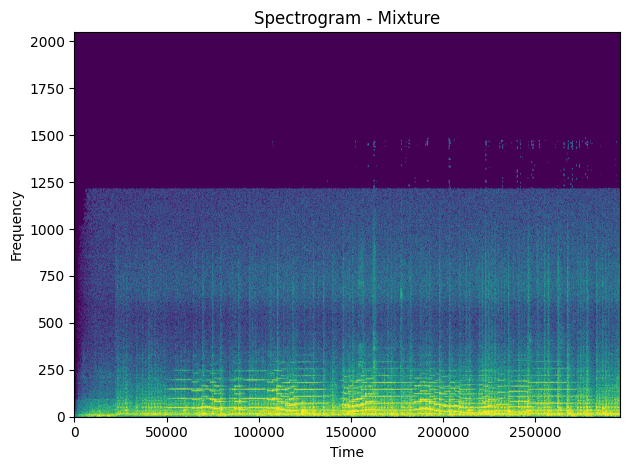

In [13]:
# Mixture Clip
plot_spectrogram(stft(mix_spec)[0], "Spectrogram - Mixture")
# Audio(mix_spec, rate=sample_rate)

# save audio 
export_audio(mix_spec, f"../data/output/pytorch_audio_hybrid_demucs/{filename_orig}_mix.wav", filetype="wav")

Drums SDR, Spectrogram, and Audio




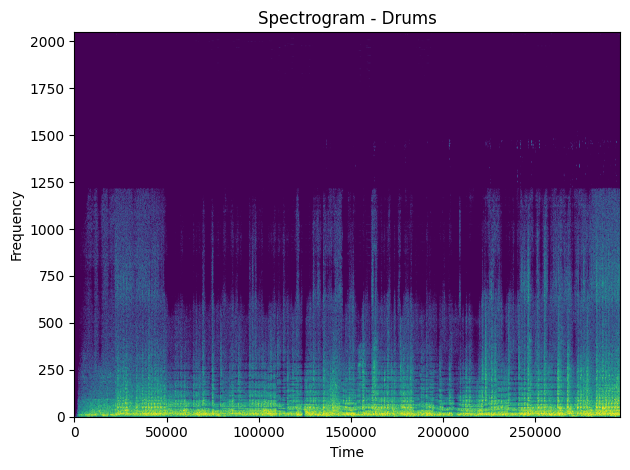

In [15]:
# Mixture Clip
plot_spectrogram(stft(drums_spec)[0], "Spectrogram - Drums")

# save audio 
export_audio(drums_spec, f"../data/output/pytorch_audio_hybrid_demucs/{filename_orig}_drums.wav", filetype="wav")

Can definitely hear the snare drums hear, isolated from the other instruments quite well, but it also sounds like it was recorded in a wind tunnel. Might be worth denoising the original live recording first

Bass SDR, Spectrogram, and Audio




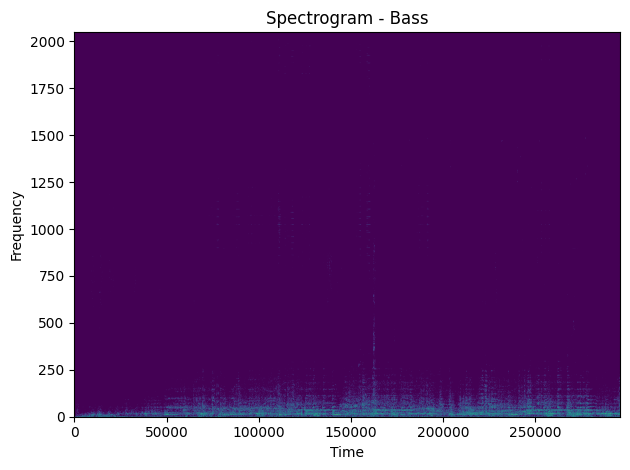

In [16]:
# Bass Clip
plot_spectrogram(stft(bass_spec)[0], "Spectrogram - Bass")

# save audio 
export_audio(bass_spec, f"../data/output/pytorch_audio_hybrid_demucs/{filename_orig}_bass.wav", filetype="wav")

The bass part captures most of the string components forming the baseline, but also captures some component of the flute and snare drums.

Vocals SDR, Spectrogram, and Audio




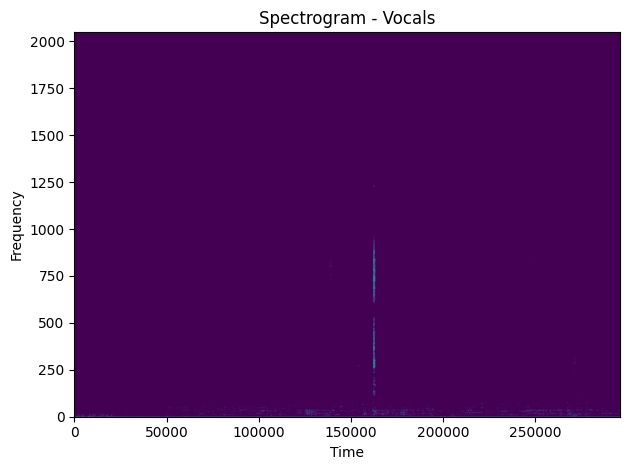

In [17]:
# Vocals Audio
plot_spectrogram(stft(vocals_spec)[0], "Spectrogram - Vocals")

# save audio 
export_audio(vocals_spec, f"../data/output/pytorch_audio_hybrid_demucs/{filename_orig}_vocals.wav", filetype="wav")

I think vocals extracted whispering from the audience??

Other SDR, Spectrogram, and Audio




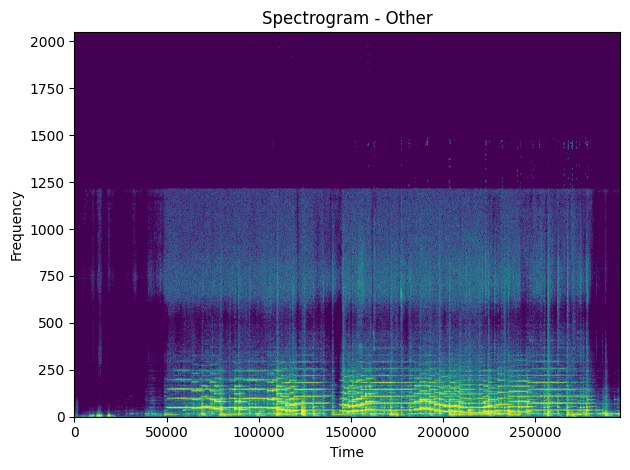

In [18]:
# Other Audio
plot_spectrogram(stft(other_spec)[0], "Spectrogram - Other")

# save audio 
export_audio(other_spec, f"../data/output/pytorch_audio_hybrid_demucs/{filename_orig}_other.wav", filetype="wav")

The flute's portion fell into this "Other" bucket. I expected to hear it from vocals, but if the model was trained on actual human voices, I see why it wasn't captured as a voice